# The Fundamentals of Machine Learning

## **Chapter 6 – Decision Trees**

Like SVMs, **Decision Trees** are versatile algorithms capable of handling classification, regression, and even multioutput tasks. They can model complex datasets but are prone to overfitting, as seen with the California housing example in Chapter 2. Decision Trees also serve as the building blocks of **Random Forests** (discussed in Chapter 7), one of the most powerful Machine Learning methods today. <br>

This chapter covers training, visualizing, and making predictions with Decision Trees, explains the **CART** training algorithm used in Scikit-Learn, explores regularization and regression applications, and concludes with their key limitations.


# Setup

First, let's import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures. We also check that Python 3.5 or later is installed (although Python 2.x may work, it is deprecated so we strongly recommend you use Python 3 instead), as well as Scikit-Learn ≥0.20.

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "decision_trees"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Training and Visualizing a Decision Tree

To understand Decision Trees, let’s build one and take a look at how it makes predictions. The following code trains a DecisionTreeClassifier on the iris dataset (see Chapter 4):

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data[:, 2:] # petal length and width
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=42)

## Making Predictions

To understand how the Decision Tree in Figure 6-1 makes predictions, start at the root node. It first checks whether the petal length is less than 2.45 cm. If yes, you move to the left child node, which is a leaf predicting **Iris setosa**.  
If the petal length is greater than 2.45 cm, you move to the right child node, which asks another question: is the petal width smaller than 1.75 cm? If yes, the tree predicts **Iris versicolor**; otherwise, it predicts **Iris virginica**. The decision process is simply a sequence of conditional tests from root to leaf.


**Code to generate Figure 6–2. Decision Tree decision boundaries**

Saving figure decision_tree_decision_boundaries_plot


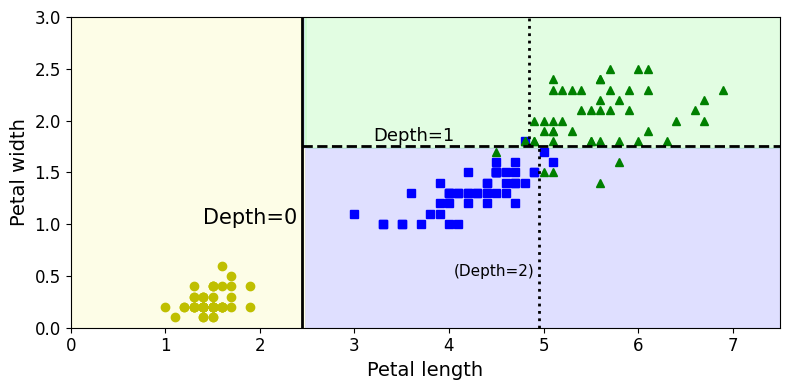

In [7]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if not iris:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris virginica")
        plt.axis(axes)
    if iris:
        plt.xlabel("Petal length", fontsize=14)
        plt.ylabel("Petal width", fontsize=14)
    else:
        plt.xlabel(r"$x_1$", fontsize=18)
        plt.ylabel(r"$x_2$", fontsize=18, rotation=0)
    if legend:
        plt.legend(loc="lower right", fontsize=14)

plt.figure(figsize=(8, 4))
plot_decision_boundary(tree_clf, X, y)
plt.plot([2.45, 2.45], [0, 3], "k-", linewidth=2)
plt.plot([2.45, 7.5], [1.75, 1.75], "k--", linewidth=2)
plt.plot([4.95, 4.95], [0, 1.75], "k:", linewidth=2)
plt.plot([4.85, 4.85], [1.75, 3], "k:", linewidth=2)
plt.text(1.40, 1.0, "Depth=0", fontsize=15)
plt.text(3.2, 1.80, "Depth=1", fontsize=13)
plt.text(4.05, 0.5, "(Depth=2)", fontsize=11)

save_fig("decision_tree_decision_boundaries_plot")
plt.show()

Figure 6-2. Decision Tree decision boundaries

# Estimating Class Probabilities

A Decision Tree can estimate the probability that an instance belongs to a specific class **k** by finding the leaf node it falls into and calculating the ratio of training instances of class **k** in that node.  
For example, a flower with petals 5 cm long and 1.5 cm wide reaches the depth-2 left leaf, which contains 54 training samples: 0 **setosa**, 49 **versicolor**, and 5 **virginica**.  
Thus, the predicted probabilities are **0% setosa**, **90.7% versicolor**, and **9.3% virginica**. The tree predicts **Iris versicolor** (class 1) since it has the highest probability.


In [8]:
tree_clf.predict_proba([[5, 1.5]])

array([[0.        , 0.90740741, 0.09259259]])

In [9]:
tree_clf.predict([[5, 1.5]])

array([1])

## Regularization Hyperparameters

We've seen that small changes in the dataset (such as a rotation) may produce a very different Decision Tree.
Now let's show that training the same model on the same data may produce a very different model every time, since the CART training algorithm used by Scikit-Learn is stochastic. To show this, we will set `random_state` to a different value than earlier:

Decision Trees make few assumptions about the data, unlike linear models that assume linear relationships. If left unrestricted, a tree can grow very complex and overfit the training data. Such models are called **nonparametric**, not because they lack parameters, but because their number of parameters is determined during training.  
In contrast, **parametric models** (e.g., linear models) have a fixed number of parameters, which limits flexibility but reduces overfitting risk.  

To prevent overfitting, Decision Trees are **regularized** by limiting their growth. The main control is the **`max_depth`** hyperparameter (default: `None`), which restricts how deep the tree can grow. Other regularization parameters include:  
- **`min_samples_split`** – minimum samples required to split a node  
- **`min_samples_leaf`** – minimum samples required for a leaf node  
- **`min_weight_fraction_leaf`** – similar to `min_samples_leaf` but as a fraction of total weights  
- **`max_leaf_nodes`** – maximum number of leaf nodes  
- **`max_features`** – maximum number of features considered at each split  

Adjusting these parameters helps balance **bias** and **variance** in the model.


In [10]:
tree_clf_tweaked = DecisionTreeClassifier(max_depth=2, random_state=40)
tree_clf_tweaked.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=40)

**Code to generate Figure 6–8. Sensitivity to training set details:**

Saving figure decision_tree_instability_plot


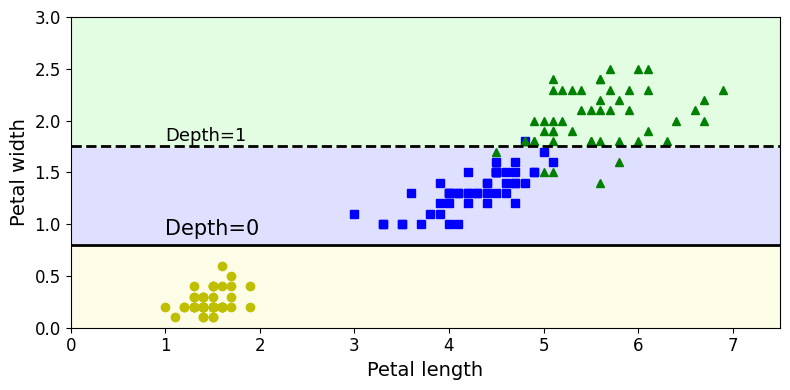

In [11]:
plt.figure(figsize=(8, 4))
plot_decision_boundary(tree_clf_tweaked, X, y, legend=False)
plt.plot([0, 7.5], [0.8, 0.8], "k-", linewidth=2)
plt.plot([0, 7.5], [1.75, 1.75], "k--", linewidth=2)
plt.text(1.0, 0.9, "Depth=0", fontsize=15)
plt.text(1.0, 1.80, "Depth=1", fontsize=13)

save_fig("decision_tree_instability_plot")
plt.show()

 Figure 6-2. Decision Tree decision boundaries

**Code to generate Figure 6–3. Regularization using min_samples_leaf:**

Saving figure min_samples_leaf_plot


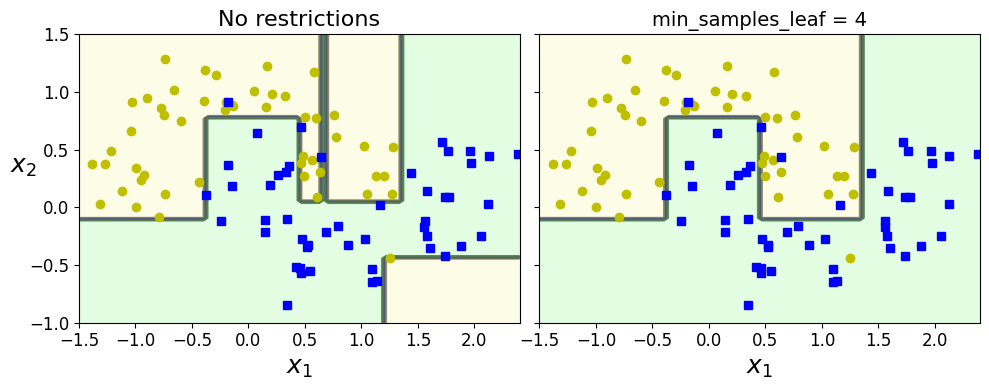

In [12]:
from sklearn.datasets import make_moons
Xm, ym = make_moons(n_samples=100, noise=0.25, random_state=53)

deep_tree_clf1 = DecisionTreeClassifier(random_state=42)
deep_tree_clf2 = DecisionTreeClassifier(min_samples_leaf=4, random_state=42)
deep_tree_clf1.fit(Xm, ym)
deep_tree_clf2.fit(Xm, ym)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(deep_tree_clf1, Xm, ym, axes=[-1.5, 2.4, -1, 1.5], iris=False)
plt.title("No restrictions", fontsize=16)
plt.sca(axes[1])
plot_decision_boundary(deep_tree_clf2, Xm, ym, axes=[-1.5, 2.4, -1, 1.5], iris=False)
plt.title("min_samples_leaf = {}".format(deep_tree_clf2.min_samples_leaf), fontsize=14)
plt.ylabel("")

save_fig("min_samples_leaf_plot")
plt.show()

Figure 6-3. Regularization using min_samples_leaf

Rotating the dataset also leads to completely different decision boundaries:

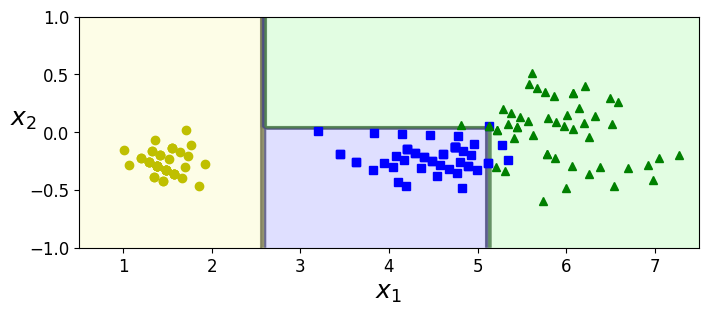

In [13]:
angle = np.pi / 180 * 20
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
Xr = X.dot(rotation_matrix)

tree_clf_r = DecisionTreeClassifier(random_state=42)
tree_clf_r.fit(Xr, y)

plt.figure(figsize=(8, 3))
plot_decision_boundary(tree_clf_r, Xr, y, axes=[0.5, 7.5, -1.0, 1], iris=False)

plt.show()

**Code to generate Figure 6–7. Sensitivity to training set rotation**

Saving figure sensitivity_to_rotation_plot


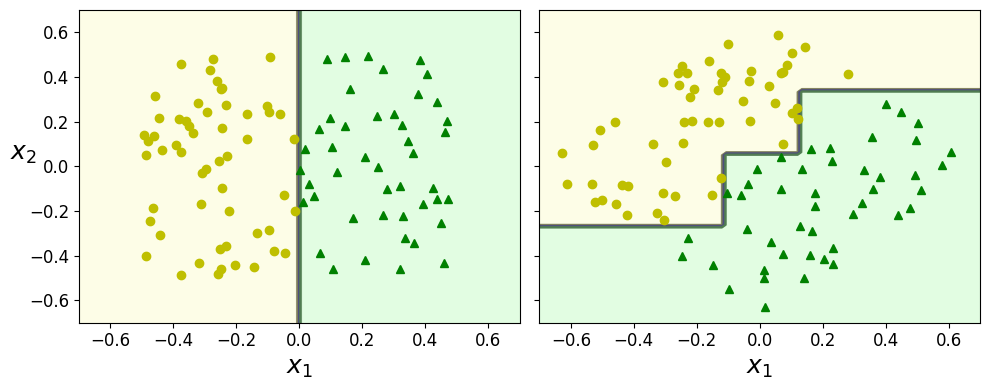

In [14]:
np.random.seed(6)
Xs = np.random.rand(100, 2) - 0.5
ys = (Xs[:, 0] > 0).astype(np.float32) * 2

angle = np.pi / 4
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
Xsr = Xs.dot(rotation_matrix)

tree_clf_s = DecisionTreeClassifier(random_state=42)
tree_clf_s.fit(Xs, ys)
tree_clf_sr = DecisionTreeClassifier(random_state=42)
tree_clf_sr.fit(Xsr, ys)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf_s, Xs, ys, axes=[-0.7, 0.7, -0.7, 0.7], iris=False)
plt.sca(axes[1])
plot_decision_boundary(tree_clf_sr, Xsr, ys, axes=[-0.7, 0.7, -0.7, 0.7], iris=False)
plt.ylabel("")

save_fig("sensitivity_to_rotation_plot")
plt.show()

 Figure 6-7. Sensitivity to training set rotation